In [1]:
import os
os.chdir(r'C:\Users\Lenovo\Desktop\Diabetes_Classifier\notebooks')
os.chdir("..")
print(os.getcwd())


C:\Users\Lenovo\Desktop\Diabetes_Classifier


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans  
from sklearn.feature_selection import mutual_info_classif
from sklearn.utils import shuffle
from src.data_preprocessing import scale,encode
from src.data_feature_engineering import features
from src.helperFunc import saveFile


In [3]:
df=pd.read_csv("data/clean/clean.csv")
y=df['diagnosis']
X=df.drop(['diagnosis'],axis=1)

In [4]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

Age_x_BMI         0.218531
age               0.188377
Cluster_5         0.175365
cluster_labels    0.164413
BMI/HDL+LDL       0.162768
lipids            0.155239
hdl               0.148718
HDL_x_LDL         0.143737
ldl               0.142239
BMI/LDL           0.130964
Cluster_2         0.118766
Cluster_0         0.116210
Cluster_1         0.109309
Cluster_4         0.109100
chol/ldl          0.108904
PCA_1             0.105244
PCA_4             0.102010
bmi               0.092864
tg                0.076947
chol              0.067465
PCA_2             0.066603
PCA_5             0.064399
Cluster_3         0.060399
cr                0.046898
bun               0.046391
PCA_6             0.031723
bun_x_cr          0.025413
PCA_3             0.009947
PCA_7             0.009470
gender            0.000000
dtype: float64


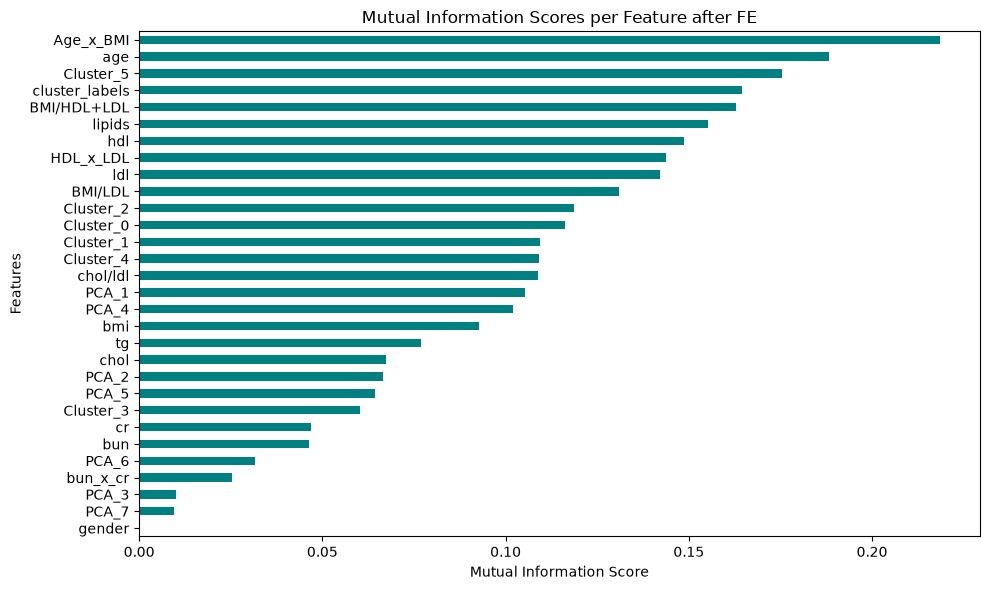

In [5]:
X_train,X_test=features(X_train,X_test)

feature= X_train.columns

mi_scores=mutual_info_classif(X_train,y_train,random_state=42,n_jobs=-1)

mi_scores_series = pd.Series(mi_scores, index=feature).sort_values(ascending=False)

print(mi_scores_series)     

plt.figure(figsize=(10, 6))
mi_scores_series.plot(kind='barh', color='teal')
plt.title('Mutual Information Scores per Feature after FE')
plt.xlabel('Mutual Information Score')
plt.ylabel('Features')
plt.gca().invert_yaxis() # Top-down display
plt.tight_layout()
plt.show()

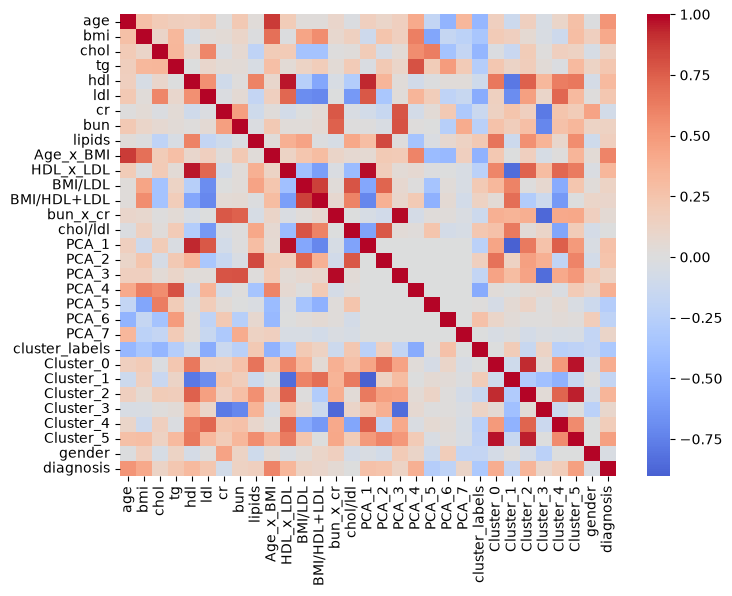

In [6]:


X_sub=pd.concat([X_train,df['diagnosis']],axis=1)
corr = X_sub.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr,
            annot=False,
            cmap="coolwarm",
            center=0)
plt.show()

In [14]:


Train_PATH="data/preprocessed/train_preprocessed.csv"
Test_PATH="data/preprocessed/test_preprocessed.csv"
Target_train_PATH="data/preprocessed/target_train.csv"
Target_test_PATH="data/preprocessed/target_test.csv"
saveFile(X_train,Train_PATH)
saveFile(y_train,Target_train_PATH)
saveFile(y_test,Target_test_PATH)
saveFile(X_test,Test_PATH)
